<a href="https://www.kaggle.com/code/sonawanelalitsunil/freelancer-earnings-job-trends-2025-ml?scriptVersionId=228640271" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/freelancer-earnings-and-job-trends/freelancer_earnings_bd.csv


## Title:
### 💼 Freelancer Earnings & Job Trends 2025 📈

## Description:
**Analyzing freelancer income patterns, job demand, and market trends to uncover the most profitable skills and emerging opportunities.**

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/freelancer-earnings-and-job-trends/freelancer_earnings_bd.csv')

In [3]:
df.head()

,Freelancer_ID,Job_Category,Platform,Experience_Level,Client_Region,Payment_Method,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Project_Type,Rehire_Rate,Marketing_Spend
0,1,Web Development,Fiverr,Beginner,Asia,Mobile Banking,180,1620,95.79,68.73,3.18,1,Fixed,40.19,53
1,2,App Development,Fiverr,Beginner,Australia,Mobile Banking,218,9078,86.38,97.54,3.44,54,Fixed,36.53,486
2,3,Web Development,Fiverr,Beginner,UK,Crypto,27,3455,85.17,86.60,4.20,46,Hourly,74.05,489
3,4,Data Entry,PeoplePerHour,Intermediate,Asia,Bank Transfer,17,5577,14.37,79.93,4.47,41,Hourly,27.58,67
4,5,Digital Marketing,Upwork,Expert,Asia,Crypto,245,5898,99.37,57.80,5.00,41,Hourly,69.09,489


In [4]:
df.tail()

,Freelancer_ID,Job_Category,Platform,Experience_Level,Client_Region,Payment_Method,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Project_Type,Rehire_Rate,Marketing_Spend
1945,1946,Graphic Design,Fiverr,Beginner,USA,Mobile Banking,143,6823,22.54,75.86,4.65,13,Hourly,26.55,133
1946,1947,SEO,Upwork,Intermediate,Middle East,Crypto,164,7942,77.20,72.01,3.29,34,Hourly,24.81,343
1947,1948,SEO,PeoplePerHour,Expert,UK,Bank Transfer,236,9838,24.64,57.37,4.67,38,Fixed,61.52,370
1948,1949,SEO,Freelancer,Intermediate,Europe,Bank Transfer,152,4492,71.07,66.41,4.08,70,Fixed,32.40,32
1949,1950,Graphic Design,Freelancer,Expert,Middle East,PayPal,247,9297,22.22,71.70,4.69,68,Fixed,45.42,236


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1950 entries, 0 to 1949
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Freelancer_ID      1950 non-null   int64  
 1   Job_Category       1950 non-null   object 
 2   Platform           1950 non-null   object 
 3   Experience_Level   1950 non-null   object 
 4   Client_Region      1950 non-null   object 
 5   Payment_Method     1950 non-null   object 
 6   Job_Completed      1950 non-null   int64  
 7   Earnings_USD       1950 non-null   int64  
 8   Hourly_Rate        1950 non-null   float64
 9   Job_Success_Rate   1950 non-null   float64
 10  Client_Rating      1950 non-null   float64
 11  Job_Duration_Days  1950 non-null   int64  
 12  Project_Type       1950 non-null   object 
 13  Rehire_Rate        1950 non-null   float64
 14  Marketing_Spend    1950 non-null   int64  
dtypes: float64(4), int64(5), object(6)
memory usage: 228.6+ KB


In [6]:
df.describe()

,Freelancer_ID,Job_Completed,Earnings_USD,Hourly_Rate,Job_Success_Rate,Client_Rating,Job_Duration_Days,Rehire_Rate,Marketing_Spend
count,1950.000000,1950.000000,1950.000000,1950.000000,1950.000000,1950.000000,1950.000000,1950.000000,1950.000000
mean,975.500000,150.864103,5017.566667,52.579774,74.951846,3.995892,44.704615,44.556913,248.517436
std,563.060832,85.480770,2926.279918,26.927584,14.615735,0.575976,26.022998,20.193842,148.084581
min,1.000000,5.000000,51.000000,5.020000,50.160000,3.000000,1.000000,10.000000,0.000000
25%,488.250000,76.000000,2419.000000,30.047500,61.917500,3.510000,22.000000,27.150000,119.000000
50%,975.500000,149.000000,5048.000000,52.285000,75.400000,3.990000,45.000000,43.920000,252.500000
75%,1462.750000,225.000000,7608.250000,75.125000,87.537500,4.500000,67.000000,61.690000,379.000000
max,1950.000000,299.000000,9991.000000,99.830000,99.990000,5.000000,89.000000,79.950000,499.000000


In [7]:
df.dtypes

Freelancer_ID          int64
Job_Category          object
Platform              object
Experience_Level      object
Client_Region         object
Payment_Method        object
Job_Completed          int64
Earnings_USD           int64
Hourly_Rate          float64
Job_Success_Rate     float64
Client_Rating        float64
Job_Duration_Days      int64
Project_Type          object
Rehire_Rate          float64
Marketing_Spend        int64
dtype: object

In [8]:
df.shape

(1950, 15)

In [9]:
df.isnull().sum()

Freelancer_ID        0
Job_Category         0
Platform             0
Experience_Level     0
Client_Region        0
Payment_Method       0
Job_Completed        0
Earnings_USD         0
Hourly_Rate          0
Job_Success_Rate     0
Client_Rating        0
Job_Duration_Days    0
Project_Type         0
Rehire_Rate          0
Marketing_Spend      0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.corr

<bound method DataFrame.corr of       Freelancer_ID       Job_Category       Platform Experience_Level  \
0                 1    Web Development         Fiverr         Beginner   
1                 2    App Development         Fiverr         Beginner   
2                 3    Web Development         Fiverr         Beginner   
3                 4         Data Entry  PeoplePerHour     Intermediate   
4                 5  Digital Marketing         Upwork           Expert   
...             ...                ...            ...              ...   
1945           1946     Graphic Design         Fiverr         Beginner   
1946           1947                SEO         Upwork     Intermediate   
1947           1948                SEO  PeoplePerHour           Expert   
1948           1949                SEO     Freelancer     Intermediate   
1949           1950     Graphic Design     Freelancer           Expert   

     Client_Region  Payment_Method  Job_Completed  Earnings_USD  Hourly_Rate  \

In [12]:
df.columns

Index(['Freelancer_ID', 'Job_Category', 'Platform', 'Experience_Level',
       'Client_Region', 'Payment_Method', 'Job_Completed', 'Earnings_USD',
       'Hourly_Rate', 'Job_Success_Rate', 'Client_Rating', 'Job_Duration_Days',
       'Project_Type', 'Rehire_Rate', 'Marketing_Spend'],
      dtype='object')

## Data visualizations

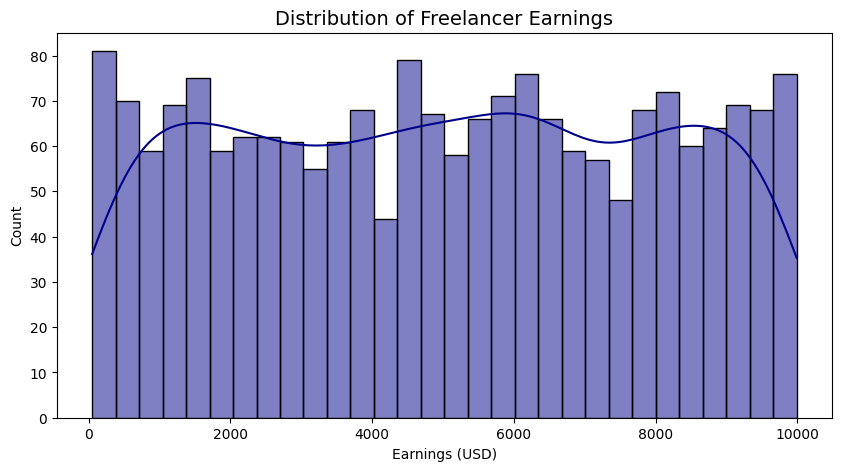

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['Earnings_USD'], bins=30, kde=True, color='darkblue')
plt.title("Distribution of Freelancer Earnings", fontsize=14)
plt.xlabel("Earnings (USD)")
plt.ylabel("Count")
plt.show()

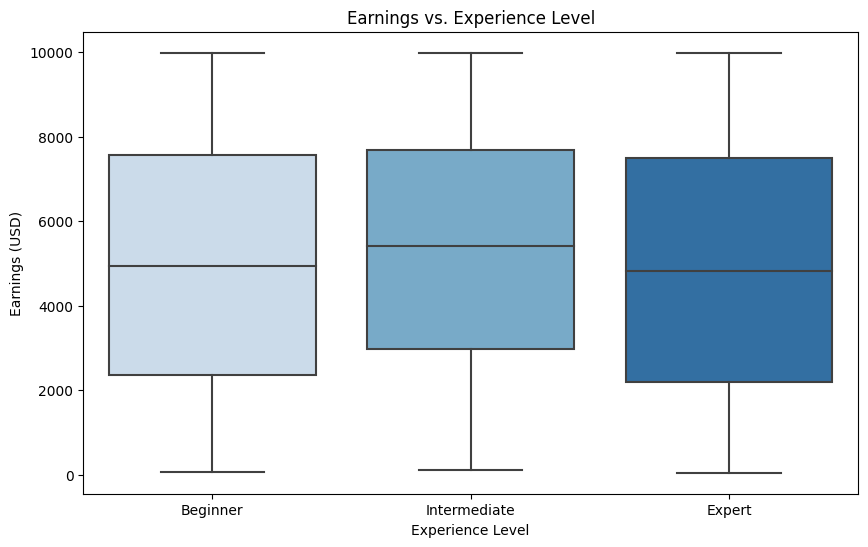

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Experience_Level', y='Earnings_USD', data=df, palette="Blues")
plt.title("Earnings vs. Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Earnings (USD)")
plt.show()

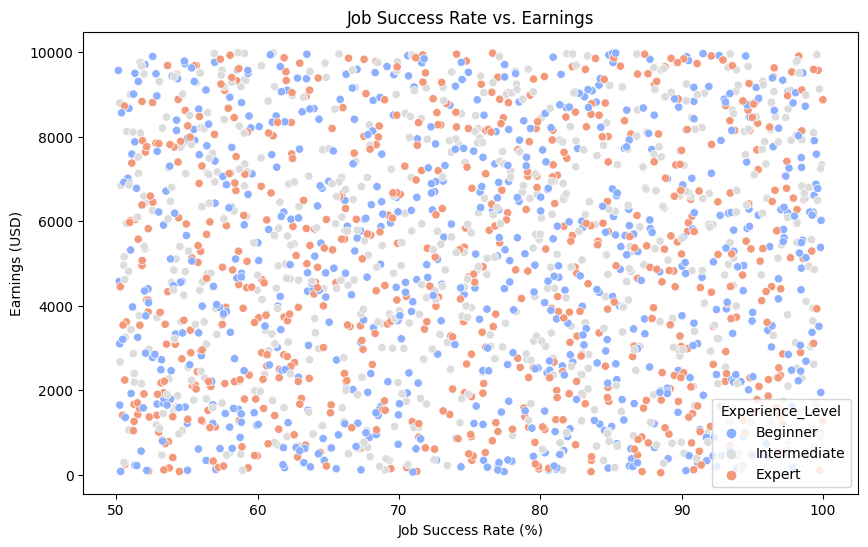

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Job_Success_Rate', y='Earnings_USD', data=df, hue="Experience_Level", palette="coolwarm")
plt.title("Job Success Rate vs. Earnings")
plt.xlabel("Job Success Rate (%)")
plt.ylabel("Earnings (USD)")
plt.show()

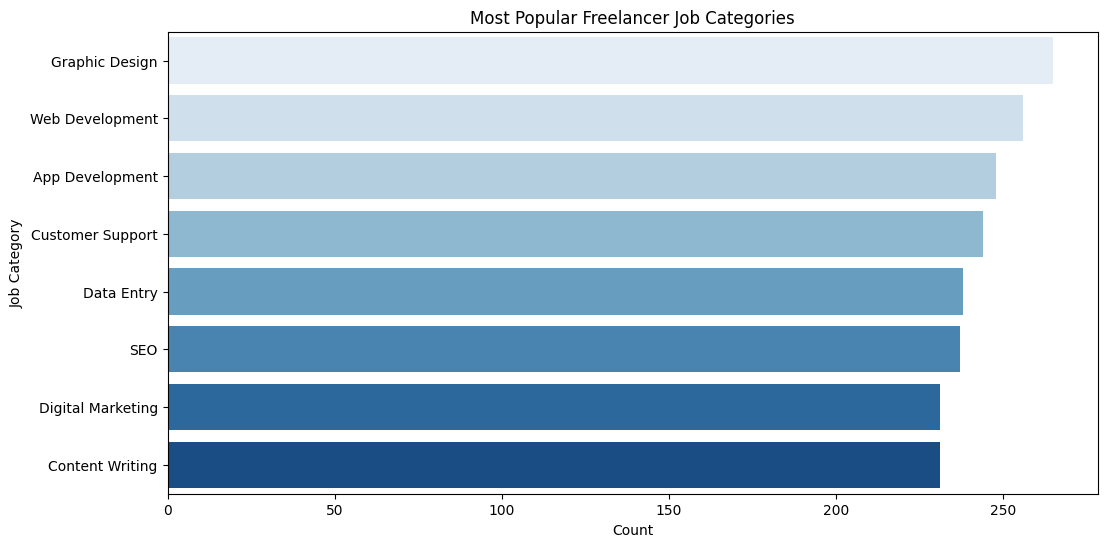

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(y='Job_Category', data=df, order=df['Job_Category'].value_counts().index, palette="Blues")
plt.title("Most Popular Freelancer Job Categories")
plt.xlabel("Count")
plt.ylabel("Job Category")
plt.show()

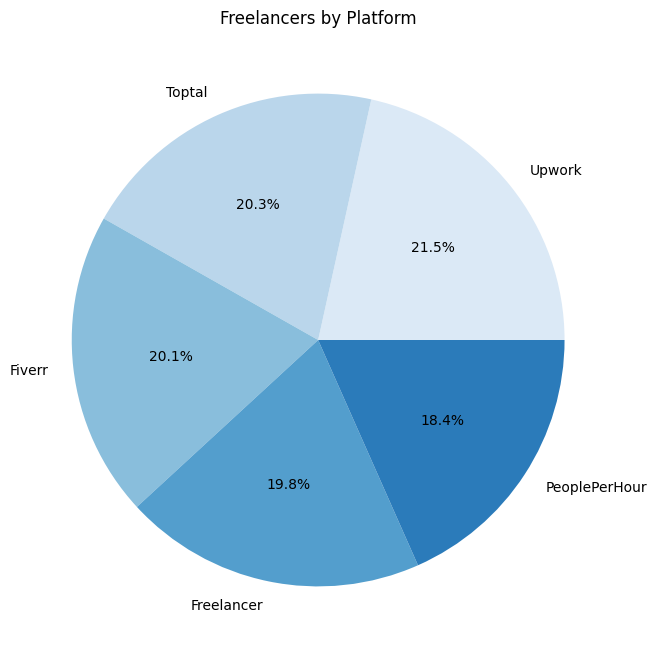

In [17]:
df['Platform'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(8,8), colors=sns.color_palette("Blues"))
plt.title("Freelancers by Platform")
plt.ylabel("")
plt.show()

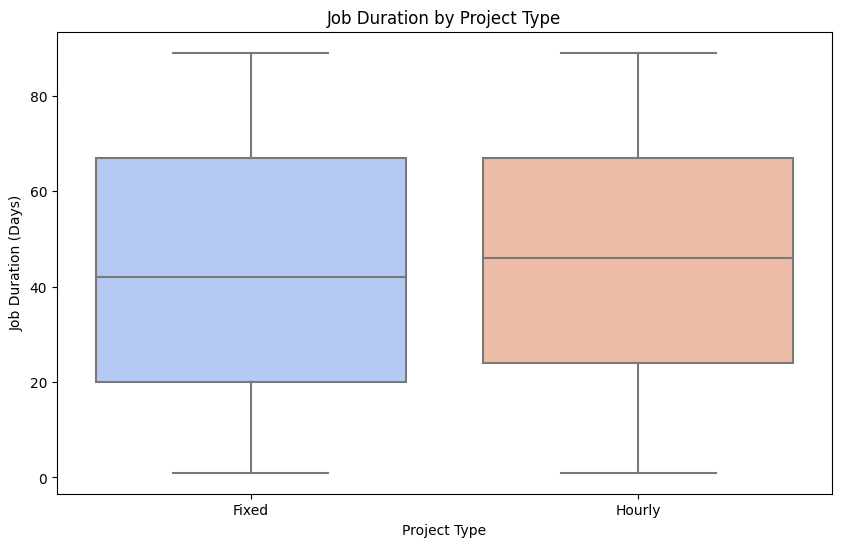

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Project_Type', y='Job_Duration_Days', data=df, palette="coolwarm")
plt.title("Job Duration by Project Type")
plt.xlabel("Project Type")
plt.ylabel("Job Duration (Days)")
plt.show()

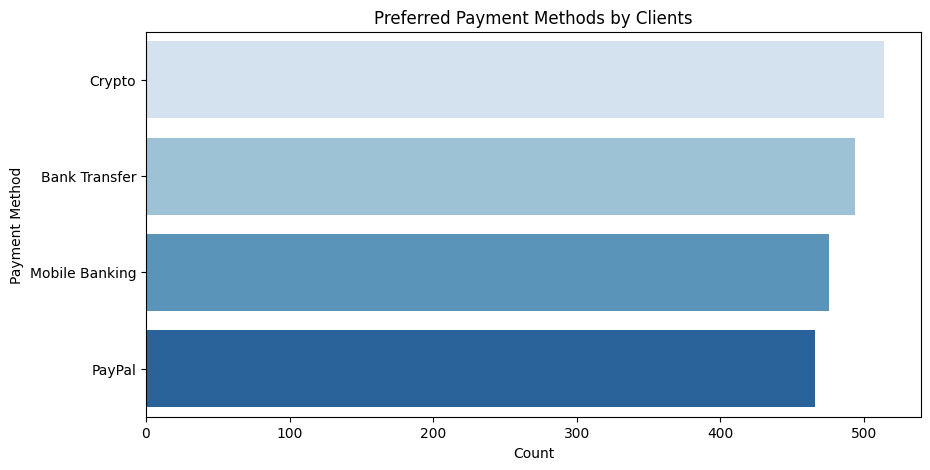

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(y='Payment_Method', data=df, order=df['Payment_Method'].value_counts().index, palette="Blues")
plt.title("Preferred Payment Methods by Clients")
plt.xlabel("Count")
plt.ylabel("Payment Method")
plt.show()

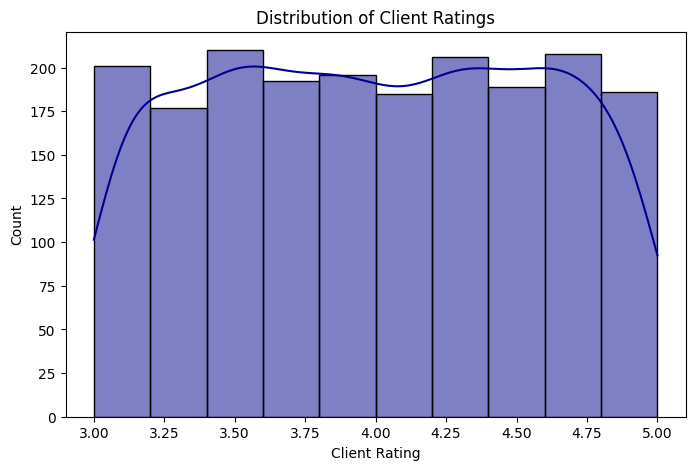

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Client_Rating'], bins=10, kde=True, color="darkblue")
plt.title("Distribution of Client Ratings")
plt.xlabel("Client Rating")
plt.ylabel("Count")
plt.show()

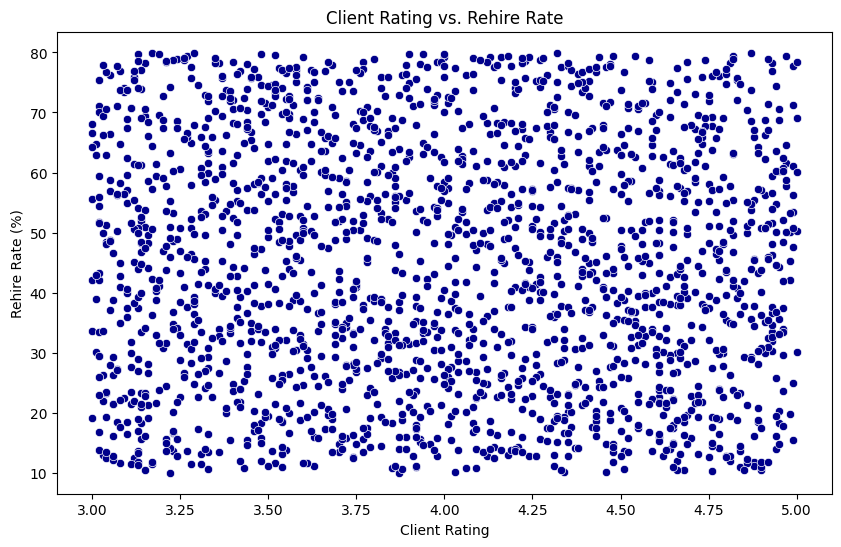

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Client_Rating', y='Rehire_Rate', data=df, color='darkblue')
plt.title("Client Rating vs. Rehire Rate")
plt.xlabel("Client Rating")
plt.ylabel("Rehire Rate (%)")
plt.show()

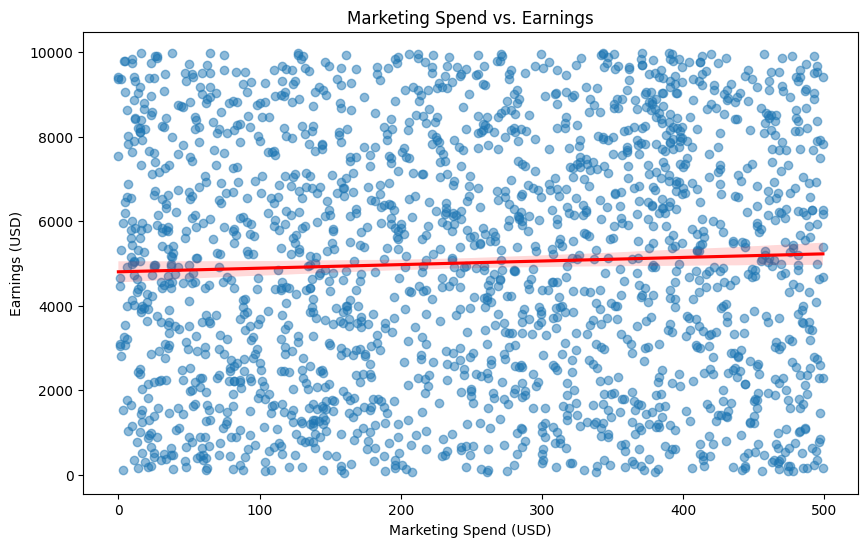

In [22]:
plt.figure(figsize=(10,6))
sns.regplot(x='Marketing_Spend', y='Earnings_USD', data=df, scatter_kws={'alpha':0.5}, line_kws={"color":"red"})
plt.title("Marketing Spend vs. Earnings")
plt.xlabel("Marketing Spend (USD)")
plt.ylabel("Earnings (USD)")
plt.show()

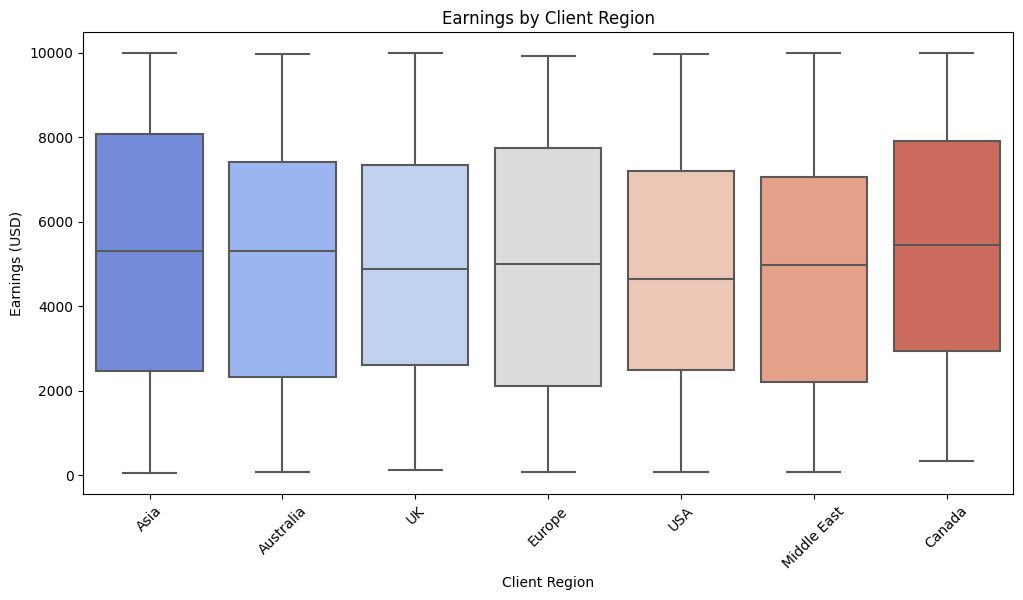

In [23]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Client_Region', y='Earnings_USD', data=df, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Earnings by Client Region")
plt.xlabel("Client Region")
plt.ylabel("Earnings (USD)")
plt.show()

## Predictive modeling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
df.dropna(inplace=True) 

In [26]:
categorical_cols = ['Job_Category', 'Platform', 'Experience_Level', 
                    'Client_Region', 'Payment_Method', 'Project_Type']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [27]:
X = df.drop(columns=['Earnings_USD']) 
y = df['Earnings_USD']  

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Model: {model.__class__.__name__}")
    print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")
    print("-" * 50)
    
    return r2

In [31]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Regressor": SVR()
}

results = {}

for name, model in models.items():
    r2 = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test)
    results[name] = r2


Model: LinearRegression
MAE: 2503.67, MSE: 8356594.36, RMSE: 2890.78, R2 Score: 0.01
--------------------------------------------------
Model: DecisionTreeRegressor
MAE: 3184.24, MSE: 15803817.34, RMSE: 3975.40, R2 Score: -0.87
--------------------------------------------------
Model: RandomForestRegressor
MAE: 2570.55, MSE: 8902053.29, RMSE: 2983.63, R2 Score: -0.05
--------------------------------------------------
Model: GradientBoostingRegressor
MAE: 2507.00, MSE: 8554751.80, RMSE: 2924.85, R2 Score: -0.01
--------------------------------------------------
Model: SVR
MAE: 2533.19, MSE: 8491420.09, RMSE: 2914.00, R2 Score: -0.00
--------------------------------------------------


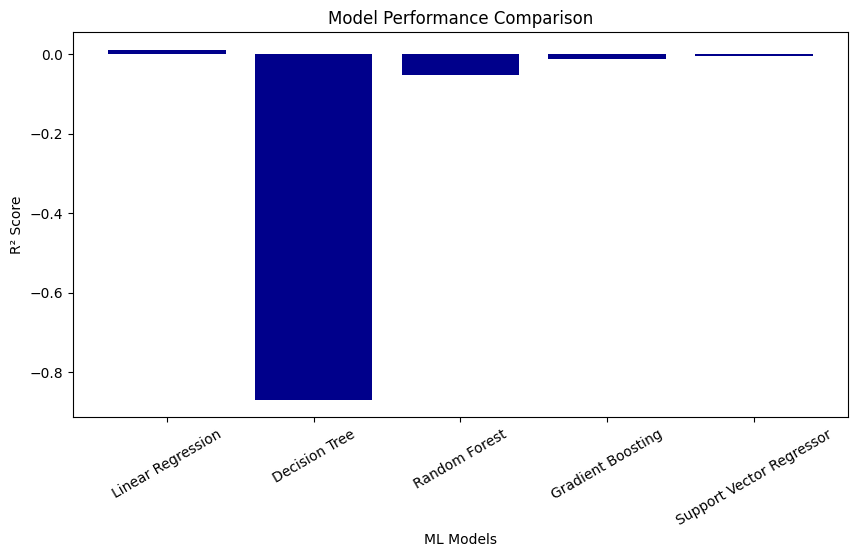

In [32]:
plt.figure(figsize=(10,5))
plt.bar(results.keys(), results.values(), color='darkblue')
plt.xlabel("ML Models")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=30)
plt.show()

## Thank you ...!! pls UPvote!!!